# Exercise 7 — Trajectory Visualiser

Run this notebook after completing the experiment in `solution.py`.

It reads three CSV files written by the experiment:
- `maze_experiment.csv` — one row per trial
- `trajectory.csv` — player position sampled every 0.1 s
- `maze_walls.csv` — wall geometry for each trial

And produces a top-down plot per trial showing:
- **Grey** — maze walls
- **Blue line** — player trajectory
- **Green circle** — start position
- **Red square** — end position
- **Gold star** — star collection event

In [1]:
import csv
import os
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Auto-find the directory containing the CSV files
_candidates = [Path('.'), Path('../..'), Path(os.path.abspath(''))]
DATA_DIR = next(
    (d for d in _candidates if (d / 'maze_experiment.csv').exists()),
    Path('.')
)
print(f'Data directory: {DATA_DIR.resolve()}')

Data directory: D:\vr-tutorial


In [2]:
def load_csv(path):
    with open(path, newline='') as f:
        return list(csv.DictReader(f))

exp_rows  = load_csv(DATA_DIR / 'maze_experiment.csv')
traj_rows = load_csv(DATA_DIR / 'trajectory.csv')
wall_rows = load_csv(DATA_DIR / 'maze_walls.csv')

print(f'Trials: {len(exp_rows)}')
print(f'Trajectory samples: {len(traj_rows)}')
print(f'Wall segments: {len(wall_rows)}')

Trials: 1
Trajectory samples: 95
Wall segments: 13


## Group data by trial

In [3]:
traj_by_trial  = defaultdict(list)   # trial -> [(x, z), ...]
event_by_trial = defaultdict(list)   # trial -> [(x, z), ...]  (collect events)
wall_by_trial  = defaultdict(list)   # trial -> [(x, z, sx, sz), ...]

for r in traj_rows:
    trial = int(r['trial'])
    pt = (float(r['x']), float(r['z']))
    traj_by_trial[trial].append(pt)
    if r['event'] == 'collect':
        event_by_trial[trial].append(pt)

for r in wall_rows:
    trial = int(r['trial'])
    wall_by_trial[trial].append((
        float(r['x']), float(r['z']),
        float(r['sx']), float(r['sz']),
    ))

## Plot trajectories

Saved → D:\vr-tutorial\exercises\ex7_maze_explorer\trajectory_plot.png


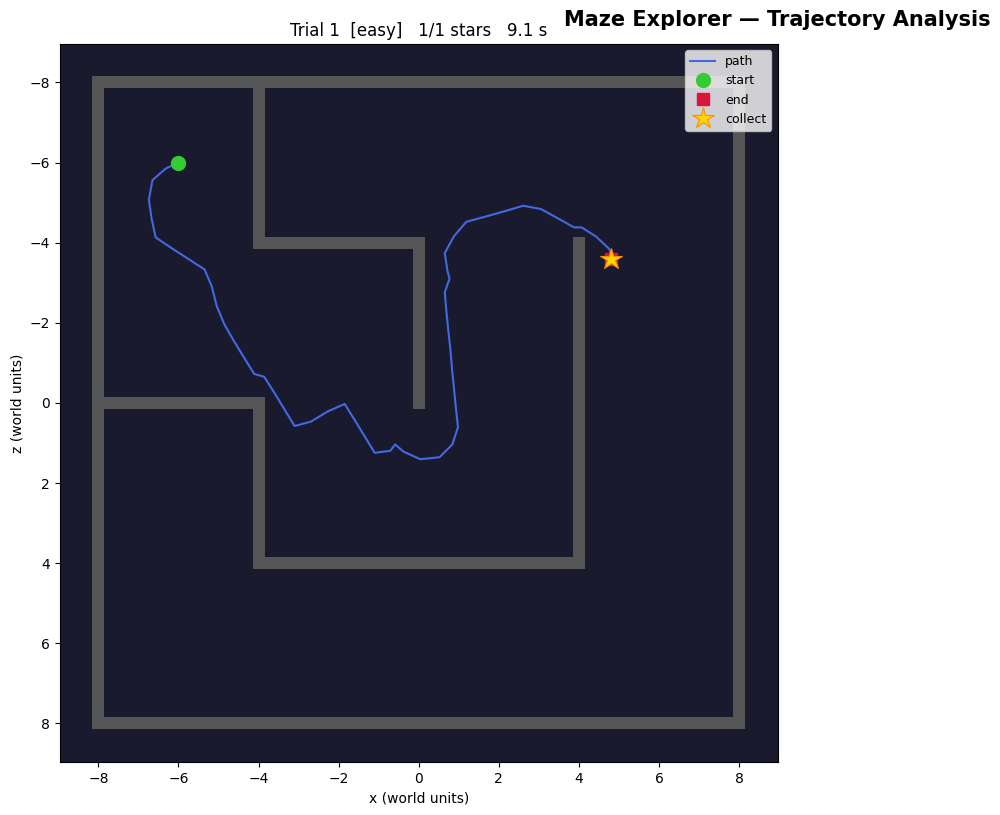

In [4]:
n_trials = len(exp_rows)
ncols = 2
nrows = (n_trials + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(8 * ncols, 8 * nrows), squeeze=False)
axes_flat = axes.flatten()

for i, exp_row in enumerate(exp_rows):
    ax    = axes_flat[i]
    trial = int(exp_row['trial'])
    cond  = exp_row['condition']

    # Draw maze walls
    for (wx, wz, sx, sz) in wall_by_trial[trial]:
        rect = mpatches.Rectangle(
            (wx - sx / 2, wz - sz / 2), sx, sz,
            linewidth=0, facecolor='#555555', zorder=1,
        )
        ax.add_patch(rect)

    # Draw trajectory
    pts = traj_by_trial[trial]
    if pts:
        xs, zs = zip(*pts)
        ax.plot(xs, zs, color='royalblue', linewidth=1.5, zorder=2, label='path')
        ax.plot(xs[0],  zs[0],  'o', color='limegreen', markersize=10, zorder=4, label='start')
        ax.plot(xs[-1], zs[-1], 's', color='crimson',   markersize=8,  zorder=4, label='end')

    # Draw collection events
    for (ex, ez) in event_by_trial[trial]:
        ax.plot(ex, ez, '*', color='gold', markersize=16,
                markeredgecolor='darkorange', markeredgewidth=0.8,
                zorder=5, label='collect')

    # Formatting
    ax.set_aspect('equal')
    ax.invert_yaxis()   # row 0 (small z) at top, matches game layout
    ax.set_facecolor('#1a1a2e')
    ax.set_title(
        f"Trial {trial}  [{cond}]   "
        f"{exp_row['collected']}/{exp_row['n_stars']} stars   "
        f"{float(exp_row['duration_s']):.1f} s",
        fontsize=12,
    )
    ax.set_xlabel('x (world units)')
    ax.set_ylabel('z (world units)')

    # Deduplicate legend entries
    handles, labels = ax.get_legend_handles_labels()
    seen = {}
    for h, l in zip(handles, labels):
        seen.setdefault(l, h)
    ax.legend(seen.values(), seen.keys(), loc='upper right', fontsize=9)

# Hide unused subplots
for j in range(n_trials, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle('Maze Explorer — Trajectory Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()

out = Path('trajectory_plot.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
print(f'Saved → {out.resolve()}')
plt.show()

## Time-series: x and z position over time

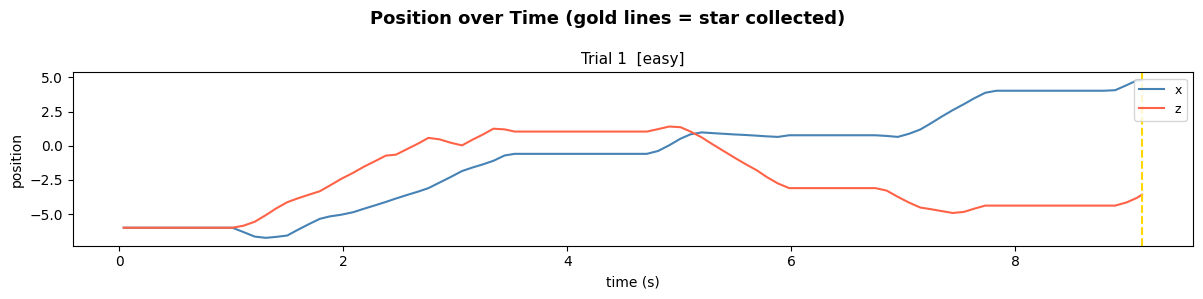

In [5]:
fig2, axes2 = plt.subplots(n_trials, 1, figsize=(12, 3 * n_trials), squeeze=False)

for i, exp_row in enumerate(exp_rows):
    ax    = axes2[i][0]
    trial = int(exp_row['trial'])

    # Get time-stamped positions
    times, xs, zs = [], [], []
    for r in traj_rows:
        if int(r['trial']) == trial:
            times.append(float(r['time_s']))
            xs.append(float(r['x']))
            zs.append(float(r['z']))

    ax.plot(times, xs, label='x', color='steelblue')
    ax.plot(times, zs, label='z', color='tomato')

    # Mark collection events
    for r in traj_rows:
        if int(r['trial']) == trial and r['event'] == 'collect':
            ax.axvline(float(r['time_s']), color='gold', linestyle='--', linewidth=1.5)

    ax.set_title(f"Trial {trial}  [{exp_row['condition']}]", fontsize=11)
    ax.set_xlabel('time (s)')
    ax.set_ylabel('position')
    ax.legend(loc='upper right', fontsize=9)

fig2.suptitle('Position over Time (gold lines = star collected)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()